# Pipeline 7: Incident Risk Prediction

**Organization:** River of Life / Lighthouse Sanctuary (INTEX)  
**Methodology:** CRISP-DM–aligned (see `pipeline_guide.md` in this folder)

---

## Executive Summary

We estimate the **probability of ≥1 incident** in the **next 60 days** per resident using case history and recent education/health signals—**decision support** for supervision, not automation.

**What this notebook delivers**
- Grouped CV by resident
- Dummy + Logistic + Random Forest
- Deployment schema for case-management UI

*Non-technical readers:* skim the Executive Summary, **Business Interpretation**, **Key Findings**, and **Recommended Actions**, then use charts in Sections 3–5 for discussion with data staff.

---


## 1. Problem Framing

### Business problem
Incidents are often handled **reactively**; staff need a **ranked watchlist** grounded in case records.

### Stakeholders
| **House parents / SW** | Daily supervision |
| **Safety officer** | Huddles |
| **Leadership** | Aggregate risk governance |

### Why this matters
Earlier attention may **prevent harm** when combined with professional judgment.

### Predictive goal (what we forecast or score)
**Binary probability** of any incident in next 60 days.

### Explanatory goal (what we want to understand)
**Logistic coefficients** describe which **recorded** factors align with higher risk (training use).

### Why predictive and explanatory are different
RF may increase recall; logistic supports **ethics reviews** and staff training narratives.

### Decision this work supports
**Weekly case conference priority list** (internal only, humane framing).

### Limitations (preview)
Labels are rare and noisy; model errors have **safety** implications—see Business Interpretation.

---


## Data Validity & Leakage Check

### How the target is defined
**y=1** if any `incident_reports` row falls in (`as_of`, `as_of+60d`].

### What information is allowed at prediction time
Incidents/education/health in **prior 90d** only; static resident fields.

### Why future information does not leak into features
Future incidents excluded from features.

### Why the train/test approach is valid
**GroupShuffleSplit / GroupKFold** on `resident_id`.

### Automated checks in this notebook
Print positive prevalence; verify no feature uses `incident_date > as_of`.

---


## 2. Data Acquisition & Preparation

**Tables:** `residents`, `incident_reports`, `education_records`, `health_wellbeing_records`.

---


In [4]:
import json
import warnings
from datetime import timedelta
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns  # noqa: F401 — used in EDA cells across generated notebooks

warnings.filterwarnings("ignore", category=UserWarning)
RANDOM_STATE = 42
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("talk", font_scale=0.85)

def find_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for p in [cwd, *cwd.parents]:
        if (p / "lighthouse_csv_v7").is_dir():
            return p
    raise FileNotFoundError(
        "Could not find lighthouse_csv_v7. Open or run from the INTEX II EDA project folder."
    )

PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "lighthouse_csv_v7"
OUTPUT_DIR = PROJECT_ROOT / "ml_pipelines" / "artifacts"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("PROJECT_ROOT:", PROJECT_ROOT.resolve())


PROJECT_ROOT: /Users/jaxon/Documents/BYU Archive/Winter 2026 - Junior Core IS/INTEX II/INTEX II EDA


In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.model_selection import GroupKFold, GroupShuffleSplit, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

res = pd.read_csv(DATA_DIR / "residents.csv", parse_dates=["date_of_admission"])
inc = pd.read_csv(DATA_DIR / "incident_reports.csv", parse_dates=["incident_date"])
edu = pd.read_csv(DATA_DIR / "education_records.csv", parse_dates=["record_date"])
hl = pd.read_csv(DATA_DIR / "health_wellbeing_records.csv", parse_dates=["record_date"])
H = 60
rows = []
anchors = pd.date_range("2023-06-01", "2025-10-01", freq="MS")
mx = inc["incident_date"].max()
sev = {"Low": 1, "Medium": 2, "High": 3}
for as_of in anchors:
    if as_of + timedelta(days=H) > mx:
        continue
    for rid in res["resident_id"].unique():
        fut = inc[(inc["resident_id"] == rid) & (inc["incident_date"] > as_of) & (inc["incident_date"] <= as_of + timedelta(days=H))]
        y = int(len(fut) > 0)
        d0 = as_of - timedelta(days=90)
        past = inc[(inc["resident_id"] == rid) & (inc["incident_date"] >= d0) & (inc["incident_date"] <= as_of)]
        n_past = len(past)
        mx_sev = past["severity"].map(sev).max() if n_past and past["severity"].map(sev).notna().any() else 0
        hp = hl[(hl["resident_id"] == rid) & (hl["record_date"] >= d0) & (hl["record_date"] <= as_of)]
        hsc = hp["general_health_score"].mean() if len(hp) else np.nan
        ep = edu[(edu["resident_id"] == rid) & (edu["record_date"] >= d0) & (edu["record_date"] <= as_of)]
        pr = ep["progress_percent"].mean() if len(ep) else np.nan
        r = res[res["resident_id"] == rid].iloc[0]
        rows.append({"resident_id": rid, "as_of": as_of, "y": y, "incidents_90d": n_past, "max_sev_90d": float(mx_sev), "health_mean_90d": hsc, "edu_prog_mean_90d": pr, "safehouse_id": int(r["safehouse_id"]), "risk_lvl": r["current_risk_level"], "status": r["case_status"]})
p = pd.DataFrame(rows)
p["health_mean_90d"] = p["health_mean_90d"].fillna(p["health_mean_90d"].median())
p["edu_prog_mean_90d"] = p["edu_prog_mean_90d"].fillna(p["edu_prog_mean_90d"].median())
adm = res.set_index("resident_id")["date_of_admission"]
p["tenure_days"] = p.apply(lambda r: (r["as_of"] - adm[r["resident_id"]]).days if pd.notna(adm[r["resident_id"]]) else 0, axis=1)
print("n=", len(p), "rate=", p["y"].mean())
NUM = ["incidents_90d", "max_sev_90d", "health_mean_90d", "edu_prog_mean_90d", "tenure_days", "safehouse_id"]
CAT = ["risk_lvl", "status"]
X, y, g = p[NUM + CAT], p["y"], p["resident_id"]
prep = ColumnTransformer([("n", StandardScaler(), NUM), ("c", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CAT)])

def pc(m):
    return Pipeline([("p", prep), ("c", m)])


n= 1740 rate= 0.0867816091954023


## 3. Exploration (EDA)

We visualize distributions and relationships **relevant to the business question**, not generic plots. Narrative interpretation follows each chart in markdown where noted.

---


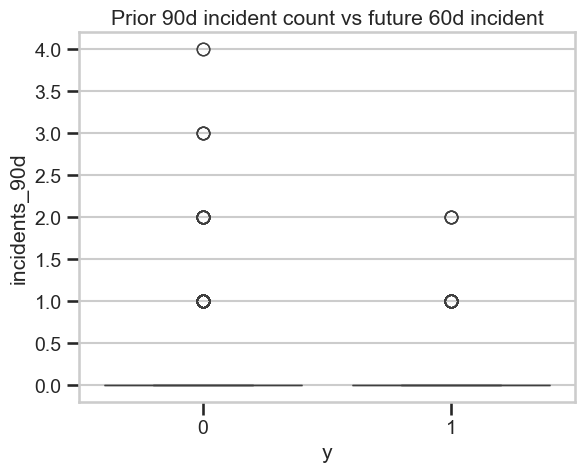

In [6]:
sns.boxplot(data=p, x="y", y="incidents_90d")
plt.title("Prior 90d incident count vs future 60d incident")
plt.show()


## 4. Modeling & Feature Selection

### Feature rationale (why these inputs)
Recent **incident load**, **severity**, **health/education** averages, **tenure**, **safehouse**, case **status**.

### Three-model strategy
1. **Baseline — Stratified dummy:** trivial rule so we never mistake “model” for “signal.”
2. **Interpretable — Balanced logistic regression:** coefficients or clear structure for **explanation** and stakeholder trust.
3. **Performance — Random Forest classifier:** stronger fit for **batch scoring**; may sacrifice some interpretability.

### Feature selection
We keep the feature set **parsimonious** and justified; where helpful, regularization (Ridge / L1) or tree-based implicit selection reduces noise. Final model choice is documented in Section 5 with **tradeoffs**.

---


dummy AUC 0.48920497954929465 recall 0.05893199233716474
logit AUC 0.6359872128881773 recall 0.4813218390804598
rf AUC 0.7716385930697753 recall 0.4977969348659004
Holdout AUC 0.6349314138258861


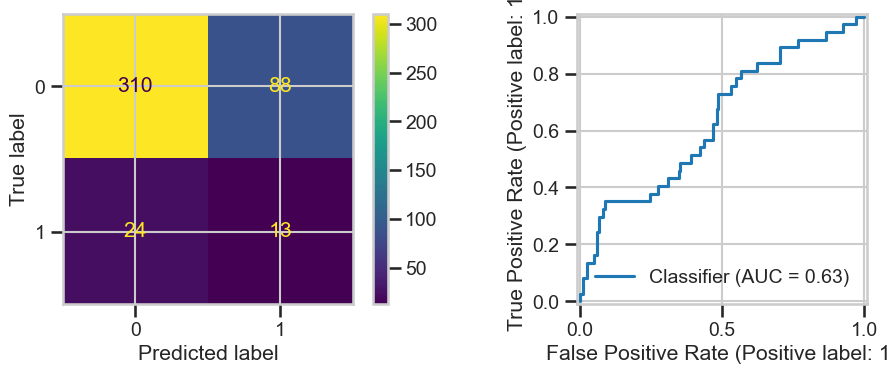

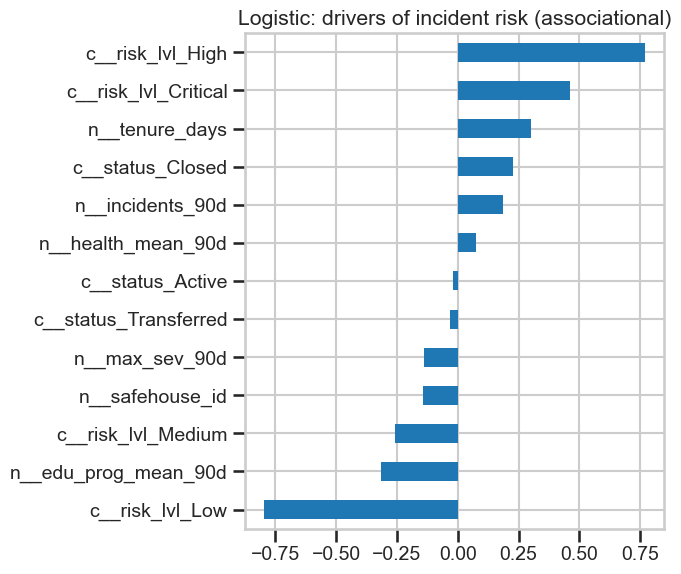

In [7]:
gkf = GroupKFold(5)
for name, m in [("dummy", DummyClassifier(strategy="stratified", random_state=RANDOM_STATE)), ("logit", LogisticRegression(max_iter=3000, class_weight="balanced", random_state=RANDOM_STATE)), ("rf", RandomForestClassifier(250, max_depth=5, class_weight="balanced_subsample", random_state=RANDOM_STATE, n_jobs=-1))]:
    sc = cross_validate(pc(m), X, y, cv=gkf, groups=g, scoring=["roc_auc", "recall", "f1"], n_jobs=-1)
    print(name, "AUC", sc["test_roc_auc"].mean(), "recall", sc["test_recall"].mean())
gss = GroupShuffleSplit(1, test_size=0.25, random_state=RANDOM_STATE)
tr, te = next(gss.split(X, y, g))
logit = pc(LogisticRegression(max_iter=3000, class_weight="balanced", random_state=RANDOM_STATE))
logit.fit(X.iloc[tr], y.iloc[tr])
pr = logit.predict_proba(X.iloc[te])[:, 1]
print("Holdout AUC", roc_auc_score(y.iloc[te], pr))
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay.from_predictions(y.iloc[te], (pr >= 0.5).astype(int), ax=ax[0])
RocCurveDisplay.from_predictions(y.iloc[te], pr, ax=ax[1])
plt.tight_layout()
plt.show()
coef = pd.Series(logit.named_steps["c"].coef_.ravel(), index=logit.named_steps["p"].get_feature_names_out()).sort_values()
coef.plot(kind="barh", figsize=(7, 6))
plt.title("Logistic: drivers of incident risk (associational)")
plt.tight_layout()
plt.show()


## 5. Evaluation & Interpretation

### Metrics
We report metrics appropriate to the task (regression: MAE, RMSE, R²; classification: accuracy, precision, recall, F1, ROC-AUC where applicable). **Grouped or held-out units** (donor, resident, safehouse) avoid optimistic scores when the same entity appears many times.

### What to look for
- **Lift over baseline:** if the interpretable and performance models barely beat the baseline, treat outputs as **weak decision support** until more data arrives.
- **Stability:** cross-validation spread indicates whether the model generalizes or chases noise.

---


## Business Interpretation

### What this means in plain English
Scores highlight residents whose **record pattern** resembles past months with incidents—**not** predictions of character.

### How reliable is this for real decisions?
Moderate-to-low; prioritize **recall** for safety huddles if policy allows extra staff time.

### What should the organization do differently?
Use list for **open questions** in supervision (“what changed?”), not labels shown to youth.

### What decision does this directly support?
**Case conference ordering** and **night-shift briefings** (internal).

### When the model is wrong
- **False positives (predicted high risk / high amount / etc., but reality was “fine”):**  
  Unnecessary anxiety or over-scrutiny → **dignity harm**; mitigate with **trauma-informed** framing.
- **False negatives (model said “low concern” but something important happened):**  
  Missed emerging crisis → **safety** risk; **mandatory** human reporting still required.

---


## 6. Causal & Relationship Analysis

### What relationships showed up in the data
Prior incidents correlate with future incidents (persistence).

### Why these are not proven causal
Interventions not randomized.

### Honest limitations
Underfitting rare events.

---


## Key Findings

- Compare to **dummy** every release.
- Tune threshold for **recall vs dignity costs**.
- Never disable **human mandatory reporting**.

---


## Recommended Actions

- Legal review of **fairness** and **consent** for internal scores.
- Train staff on **false positive** handling.

---


## 7. Deployment Plan

### What triggers scoring
**Nightly** batch after case notes sync (or weekly if data latency).

### Where results appear in the .NET application
**.NET Case Management → Resident roster** with internal-only `risk_band` column; detail view shows **top 3 drivers** (plain language).

### Who uses the output and how
| **Social worker** | Conference prep |
| **House supervisor** | Shift handoff |

### PostgreSQL table schema

```sql
CREATE TABLE resident_incident_risk (
  id BIGSERIAL PRIMARY KEY,
  resident_id INTEGER NOT NULL,
  as_of_date DATE NOT NULL,
  horizon_days INTEGER NOT NULL DEFAULT 60,
  incident_risk_probability DOUBLE PRECISION NOT NULL,
  risk_band VARCHAR(12),
  model_version VARCHAR(40) NOT NULL,
  drivers_json JSONB,
  scored_at TIMESTAMPTZ NOT NULL DEFAULT NOW(),
  UNIQUE (resident_id, as_of_date, horizon_days, model_version)
);
```

### Example upsert (batch job after training/scoring)

```sql
INSERT INTO resident_incident_risk (resident_id, as_of_date, horizon_days, incident_risk_probability, risk_band, model_version, drivers_json)
VALUES (8, DATE '2026-04-07', 60, 0.41, 'Medium', 'incident_v2', '[{"factor":"recent incidents"}]'::jsonb)
ON CONFLICT (resident_id, as_of_date, horizon_days, model_version)
DO UPDATE SET incident_risk_probability = EXCLUDED.incident_risk_probability, risk_band = EXCLUDED.risk_band, drivers_json = EXCLUDED.drivers_json, scored_at = NOW();
```

### Python → PostgreSQL → .NET data flow
1. Scheduled **batch job** (e.g., nightly Airflow / Azure Function / Windows Task Scheduler) runs this notebook’s scoring script or a `joblib` loader.
2. Script reads the latest warehouse export or DB replica, builds features **as of `run_date`**, computes predictions.
3. Results are **UPSERTed** into the table below (idempotent per natural key).
4. The **.NET** admin API reads via EF Core or Dapper; UI shows sortable lists, filters, and **no raw model internals** to end users unless “explain” panel is explicitly designed.

Map logistic coefficients to **plain-language** driver strings in ETL—not raw `num__` names in UI.

---


In [8]:
from joblib import dump
final = pc(RandomForestClassifier(250, max_depth=5, class_weight="balanced_subsample", random_state=RANDOM_STATE, n_jobs=-1))
final.fit(X, y)
dump(final, OUTPUT_DIR / "incident_risk_v2.joblib")


['/Users/jaxon/Documents/BYU Archive/Winter 2026 - Junior Core IS/INTEX II/INTEX II EDA/ml_pipelines/artifacts/incident_risk_v2.joblib']